In [5]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("data/gold_match.csv")

Test season: 2025/2026
                 Model         MAE
  Model: Random Forest  898.573846
Baseline: Same Fixture 1410.076923
  Baseline: Season Avg 1416.022189
Baseline: Opponent Avg 1501.785897


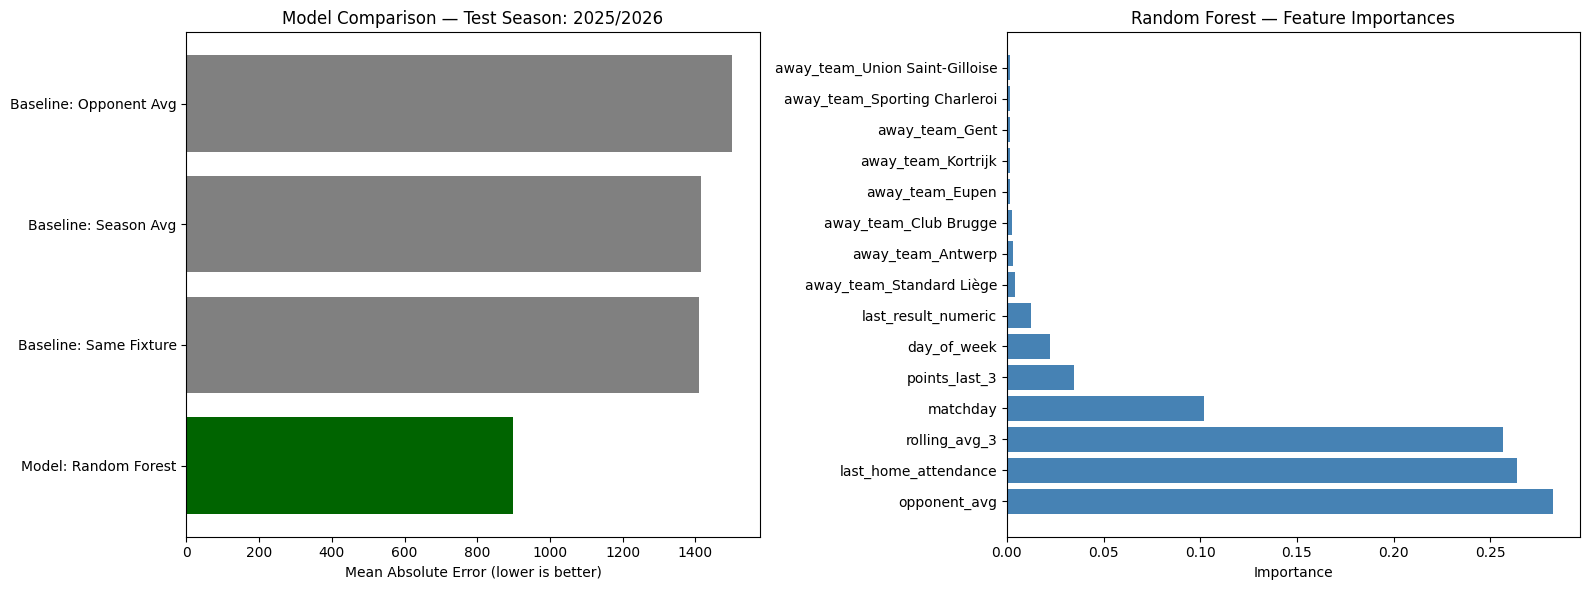

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["day_of_week"] = df["match_date"].dt.dayofweek
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

seasons = sorted(df["season"].unique())
test_season = seasons[-1]
print(f"Test season: {test_season}")

train = df[df["season"] != test_season].copy()
test  = df[df["season"] == test_season].copy()

last_known_attendance = train["tickets_scanned"].iloc[-1]
last_known_rolling    = train["tickets_scanned"].tail(3).mean()
test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
test["rolling_avg_3"]        = test["rolling_avg_3"].fillna(last_known_rolling)

opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

features = ["away_team", "matchday", "day_of_week", "competition_name", "last_result_numeric", "points_last_3", "opponent_avg", "last_home_attendance", "rolling_avg_3"]

X_train = pd.get_dummies(train[features], columns=["away_team", "competition_name"], drop_first=True)
X_test  = pd.get_dummies(test[features],  columns=["away_team", "competition_name"], drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train["tickets_scanned"]
y_test  = test["tickets_scanned"]

season_avg   = train["tickets_scanned"].mean()
opponent_avg = test["away_team"].map(opponent_avg_train).fillna(season_avg)
same_fixture = train.groupby("away_team")["tickets_scanned"].last()

mae_season   = mean_absolute_error(y_test, [season_avg] * len(y_test))
mae_opponent = mean_absolute_error(y_test, opponent_avg)
mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg))

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

results_clean = {
    "Baseline: Season Avg":   mae_season,
    "Baseline: Same Fixture": mae_fixture,
    "Baseline: Opponent Avg": mae_opponent,
    "Model: Random Forest":   mae_rf,
}

results_df = pd.DataFrame(results_clean.items(), columns=["Model", "MAE"]).sort_values("MAE")
print(results_df.to_string(index=False))

importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

colors = ["darkgreen" if m == "Model: Random Forest" else "grey" for m in results_df["Model"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(results_df["Model"], results_df["MAE"], color=colors)
axes[0].set_xlabel("Mean Absolute Error (lower is better)")
axes[0].set_title(f"Model Comparison — Test Season: {test_season}")

axes[1].barh(importance_df["feature"], importance_df["importance"], color="steelblue")
axes[1].set_xlabel("Importance")
axes[1].set_title("Random Forest — Feature Importances")

plt.tight_layout()
plt.show()

Test season: 2025/2026
Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
                   Model         MAE
       Model: RF (tuned)  909.829757
Model: RF (top features)  973.537692
    Baseline: Season Avg 1306.675700
  Baseline: Opponent Avg 1335.090780
  Baseline: Same Fixture 2117.680851


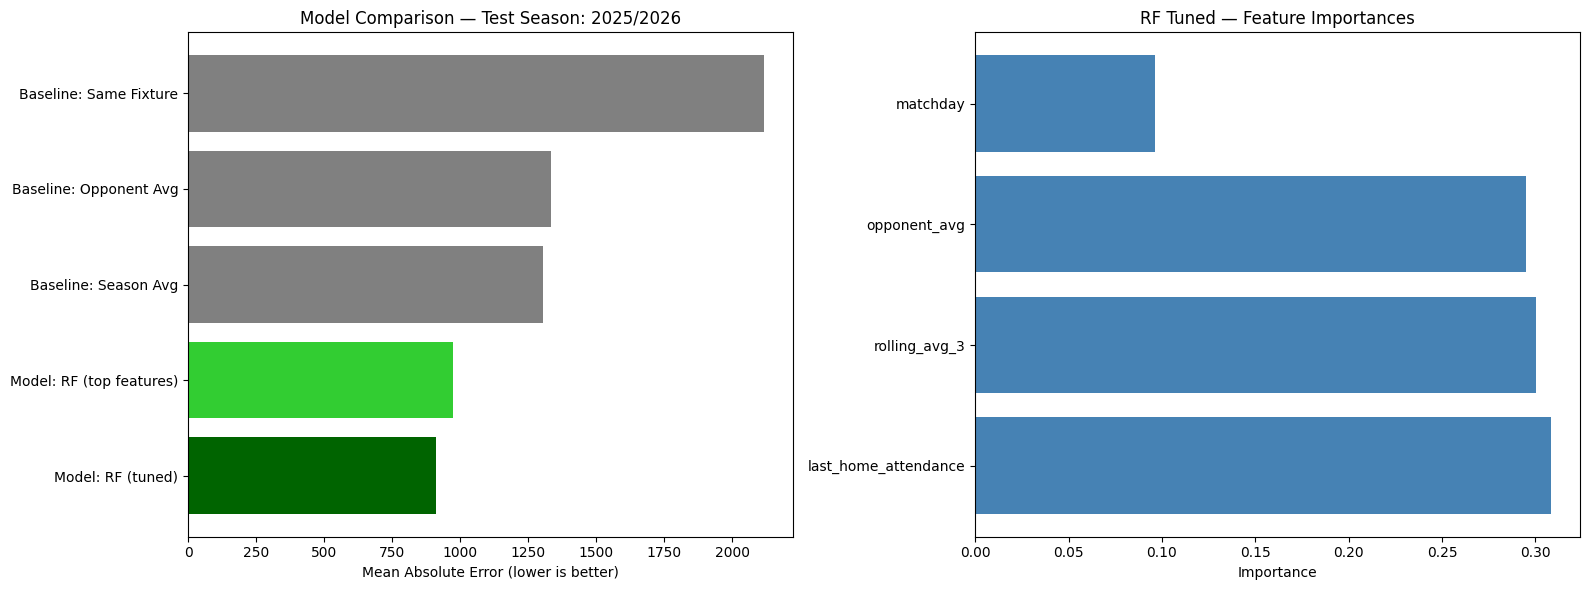

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

match   = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

df = df.sort_values(["away_team", "match_date"])
df["season_avg"]      = df.groupby("season")["tickets_scanned"].transform("mean")
df["fixture_last_year"] = df.groupby("away_team")["tickets_scanned"].shift(1)
df["opponent_avg_bl"] = df.groupby("away_team")["tickets_scanned"].transform("mean")

df_baseline = df.dropna(subset=["fixture_last_year"])
mae_season   = mean_absolute_error(df_baseline["tickets_scanned"], df_baseline["season_avg"])
mae_fixture  = mean_absolute_error(df_baseline["tickets_scanned"], df_baseline["fixture_last_year"])
mae_opponent = mean_absolute_error(df_baseline["tickets_scanned"], df_baseline["opponent_avg_bl"])

seasons = sorted(df["season"].unique())
test_season = seasons[-1]
print(f"Test season: {test_season}")

train = df[df["season"] != test_season].copy()
test  = df[df["season"] == test_season].copy()

last_known_attendance = train["tickets_scanned"].iloc[-1]
last_known_rolling    = train["tickets_scanned"].tail(3).mean()
test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
test["rolling_avg_3"]        = test["rolling_avg_3"].fillna(last_known_rolling)

opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

features = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday"]

X_train = train[features]
X_test  = test[features]
y_train = train["tickets_scanned"]
y_test  = test["tickets_scanned"]

rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
mae_rf_base = mean_absolute_error(y_test, rf_base.predict(X_test))

param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")

rf_tuned = grid_search.best_estimator_
mae_rf_tuned = mean_absolute_error(y_test, rf_tuned.predict(X_test))

results_clean = {
    "Baseline: Season Avg":     mae_season,
    "Baseline: Same Fixture":   mae_fixture,
    "Baseline: Opponent Avg":   mae_opponent,
    "Model: RF (top features)": mae_rf_base,
    "Model: RF (tuned)":        mae_rf_tuned,
}

results_df = pd.DataFrame(results_clean.items(), columns=["Model", "MAE"]).sort_values("MAE")
print(results_df.to_string(index=False))

importance_df = pd.DataFrame({
    "feature":    features,
    "importance": rf_tuned.feature_importances_
}).sort_values("importance", ascending=False)

def bar_color(m):
    if m == "Model: RF (tuned)":        return "darkgreen"
    if m == "Model: RF (top features)": return "limegreen"
    if "Baseline" in m:                 return "grey"
    return "steelblue"

colors = [bar_color(m) for m in results_df["Model"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(results_df["Model"], results_df["MAE"], color=colors)
axes[0].set_xlabel("Mean Absolute Error (lower is better)")
axes[0].set_title(f"Model Comparison — Test Season: {test_season}")

axes[1].barh(importance_df["feature"], importance_df["importance"], color="steelblue")
axes[1].set_xlabel("Importance")
axes[1].set_title("RF Tuned — Feature Importances")

plt.tight_layout()
plt.show()

Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1465 | Opponent Avg: 1853 | Season Avg: 1828 | Same Fixture: 2159 | n=13
2023/2024 — RF: 1801 | Opponent Avg: 2330 | Season Avg: 2321 | Same Fixture: 2635 | n=19
2024/2025 — RF: 1372 | Opponent Avg: 1317 | Season Avg: 1601 | Same Fixture: 1312 | n=20
2025/2026 — RF: 929 | Opponent Avg: 1502 | Season Avg: 1416 | Same Fixture: 1410 | n=13


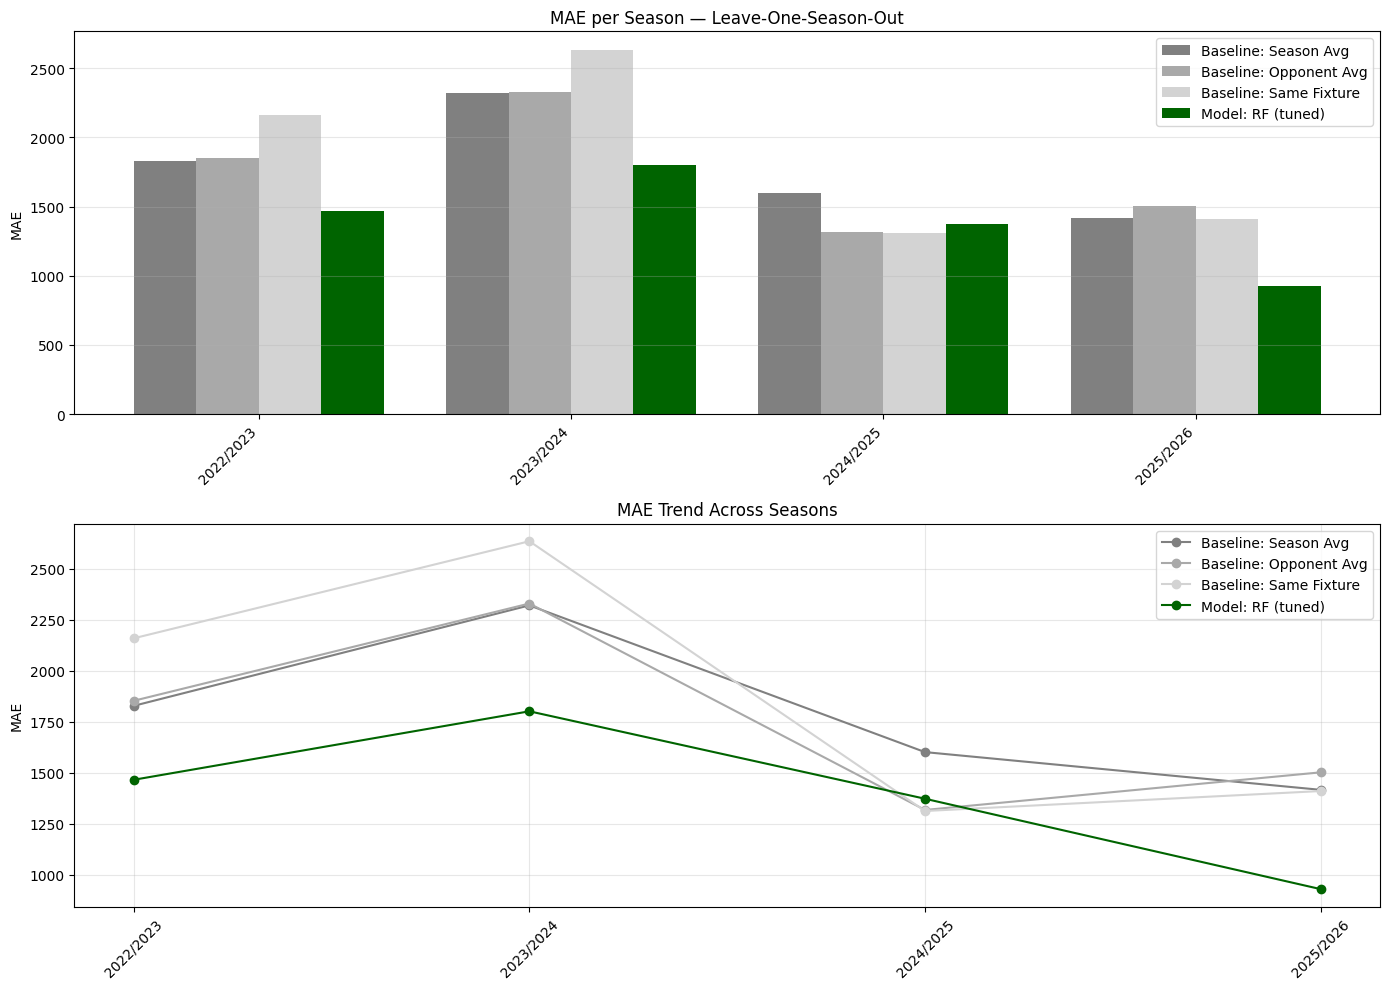

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

features = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday"]

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy()
    test  = df[df["season"] == test_season].copy()

    if len(train) < 10 or len(test) < 5:
        continue

    last_known_attendance = train["tickets_scanned"].iloc[-1]
    last_known_rolling    = train["tickets_scanned"].tail(3).mean()
    test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
    test["rolling_avg_3"]        = test["rolling_avg_3"].fillna(last_known_rolling)

    opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
    train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
    test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = train[features]
    X_test  = test[features]
    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["away_team"].map(opponent_avg_train).fillna(season_avg_val)
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":               test_season,
        "n_matches":            len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

results_df = pd.DataFrame(season_results).set_index("season")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

cols = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x = range(len(results_df))
width = 0.2

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — Leave-One-Season-Out")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [23]:
print(df[df["season"] == "2023/2024"].groupby("stage")["tickets_scanned"])
print(df[df["season"] == "2023/2024"].groupby("stage")["tickets_scanned"].agg(["mean", "count", "std"]).sort_values("mean", ascending=False).to_string())

                                         mean  count          std
stage                                                            
Regular Season                    9194.214286     14  1098.778495
Conference League Play-off Group  5361.400000      5   935.035454


Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1544 | Opponent Avg: 1853 | Season Avg: 1828 | Same Fixture: 2159 | n=13
2023/2024 — RF: 1774 | Opponent Avg: 2330 | Season Avg: 2321 | Same Fixture: 2635 | n=19
2024/2025 — RF: 1358 | Opponent Avg: 1317 | Season Avg: 1601 | Same Fixture: 1312 | n=20
2025/2026 — RF: 618 | Opponent Avg: 1502 | Season Avg: 1416 | Same Fixture: 1410 | n=13


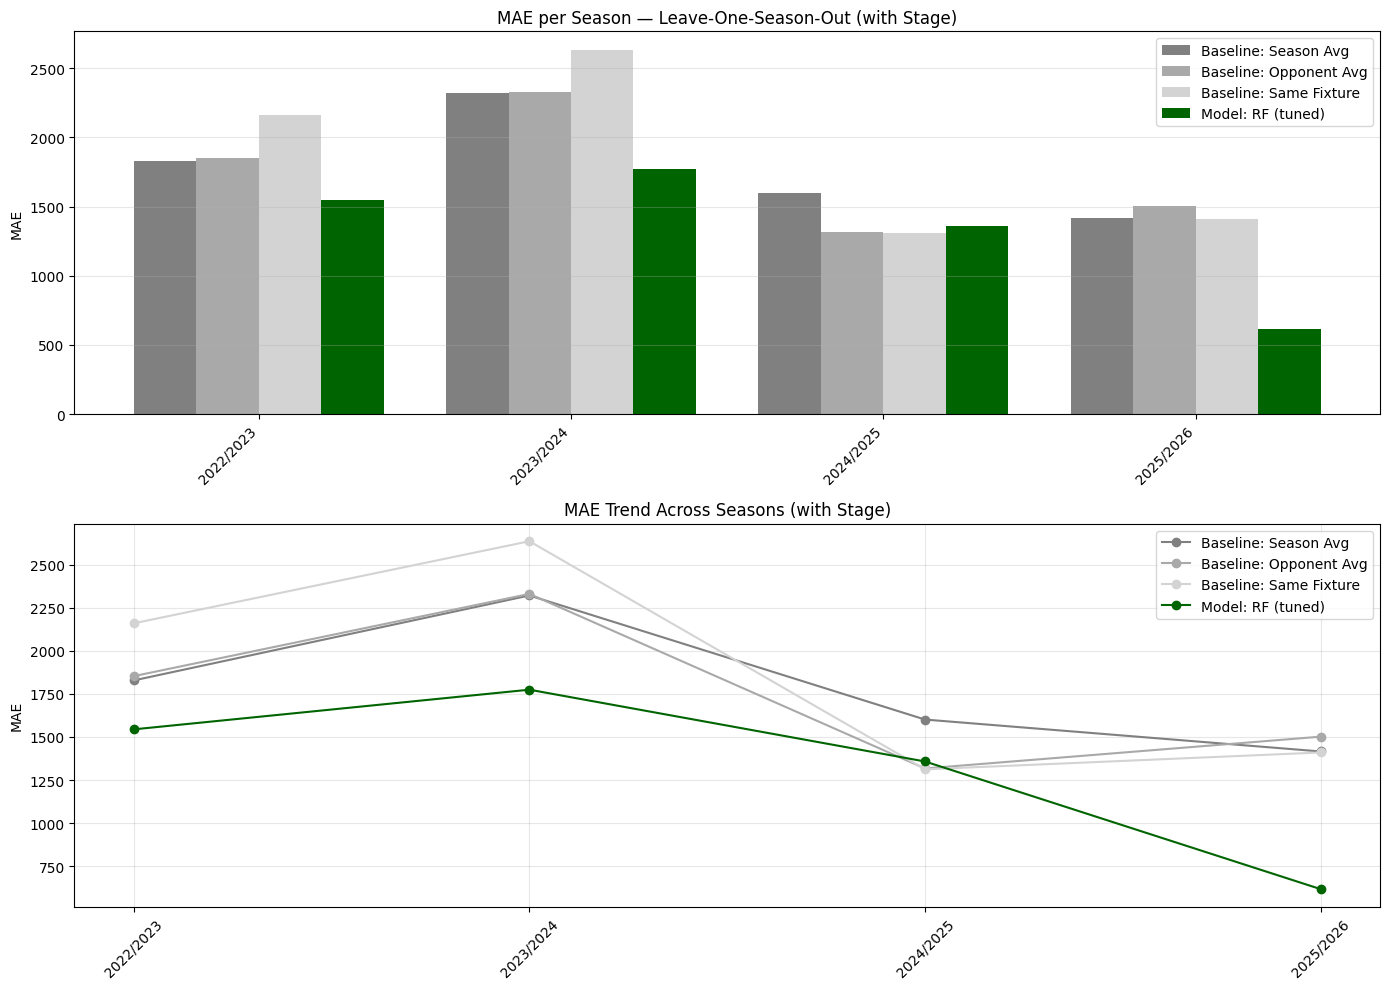

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

features = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday", "stage"]

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy()
    test  = df[df["season"] == test_season].copy()

    if len(train) < 10 or len(test) < 5:
        continue

    last_known_attendance = train["tickets_scanned"].iloc[-1]
    last_known_rolling    = train["tickets_scanned"].tail(3).mean()
    test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
    test["rolling_avg_3"]        = test["rolling_avg_3"].fillna(last_known_rolling)

    opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
    train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
    test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = pd.get_dummies(train[features], columns=["stage"], drop_first=True)
    X_test  = pd.get_dummies(test[features],  columns=["stage"], drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["away_team"].map(opponent_avg_train).fillna(season_avg_val)
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — Leave-One-Season-Out (with Stage)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons (with Stage)")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1354 | Opponent Avg: 1740 | Season Avg: 1860 | Same Fixture: 2193 | n=13
2023/2024 — RF: 2301 | Opponent Avg: 2544 | Season Avg: 2523 | Same Fixture: 3191 | n=14
2024/2025 — RF: 1435 | Opponent Avg: 1088 | Season Avg: 1465 | Same Fixture: 1507 | n=15
2025/2026 — RF: 1404 | Opponent Avg: 2045 | Season Avg: 1844 | Same Fixture: 1569 | n=13


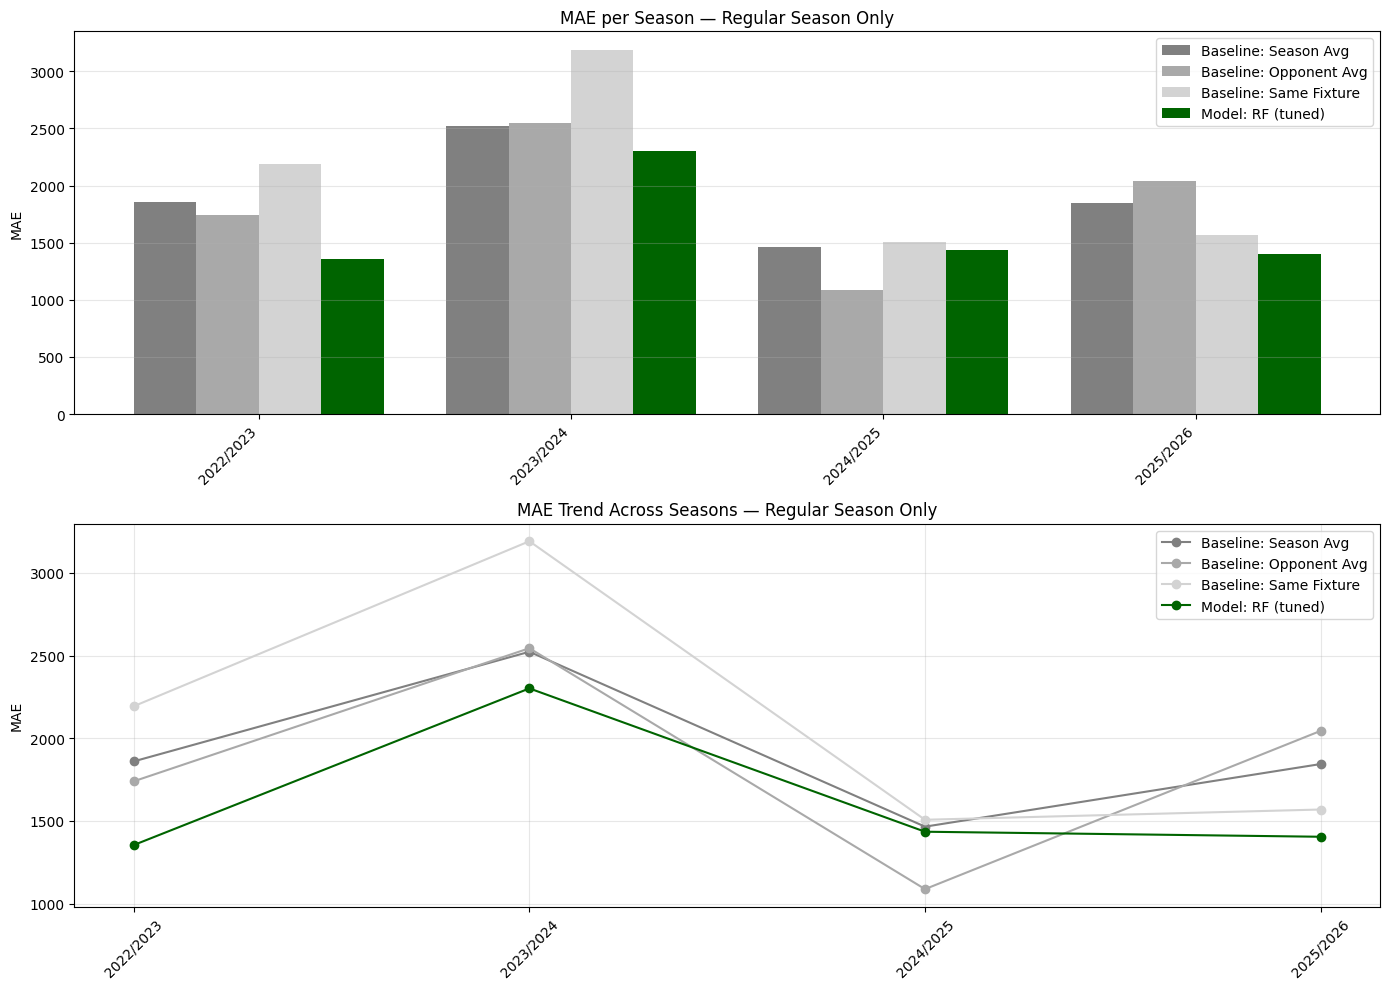

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df[df["stage"] == "Regular Season"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

features = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday"]

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy()
    test  = df[df["season"] == test_season].copy()

    if len(train) < 10 or len(test) < 5:
        continue

    last_known_attendance = train["tickets_scanned"].iloc[-1]
    last_known_rolling    = train["tickets_scanned"].tail(3).mean()
    test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
    test["rolling_avg_3"]        = test["rolling_avg_3"].fillna(last_known_rolling)

    opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
    train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
    test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = train[features]
    X_test  = test[features]
    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["away_team"].map(opponent_avg_train).fillna(season_avg_val)
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — Regular Season Only")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons — Regular Season Only")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [29]:
print(df.columns)
print(df[["league_position_home", "league_position_away"]].describe())
print(df[["league_position_home", "league_position_away", "tickets_scanned"]].corr())

Index(['match_id', 'match_date', 'kickoff_time_local', 'match_date_utc',
       'kickoff_time_utc', 'matchday', 'competition_id', 'competition_name',
       'season', 'season_id', 'stage', 'home_team_id', 'home_team',
       'home_team_code', 'away_team_id', 'away_team', 'away_team_code',
       'venue', 'winner', 'result_home', 'goals_home_ht', 'goals_away_ht',
       'goals_home_ft', 'goals_away_ft', 'is_home_match',
       'last_result_vs_opponent', 'tickets_scanned', 'tickets_sold_b2c',
       'tickets_sold_b2b', 'tickets_sold_total', 'seasonpass_holders',
       'tickets_trib1', 'tickets_trib2_thuis', 'tickets_trib2_uit',
       'tickets_trib3', 'tickets_trib4', 'match_date_y', 'weather_temp_max_c',
       'weather_temp_min_c', 'weather_temp_mean_c', 'weather_precipitation_mm',
       'weather_rain_mm', 'weather_snowfall_cm', 'weather_windspeed_max_kmh',
       'weather_sunshine_hours', 'weather_code', 'weather_temp_deviation',
       'weather_score', 'weather_description', 'has_p

KeyError: "None of [Index(['league_position_home', 'league_position_away'], dtype='object')] are in the [columns]"